<a href="https://colab.research.google.com/github/kavipriya30/AI-Powered-Digital-Twin-for-smart-campus-infrastructure/blob/main/DS_Day01_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [65]:
data = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Dataset Shape:", data.shape)
display(data.head())

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [66]:
print("Column Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
Envi

In [67]:
display(data.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [68]:
display(data.describe(include='object'))

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [69]:
data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (1470, 35)


In [70]:
print(data.isnull().sum().sum())

0


In [71]:
print(data['Attrition'].value_counts())

print("\nAttrition Percentage:")
print(data['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [72]:
data['Attrition_Flag'] = data['Attrition'].map({
    'Yes': 1,
    'No': 0
})

display(data[['Attrition', 'Attrition_Flag']].head())

,Attrition,Attrition_Flag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [73]:
attrition_rate = data['Attrition_Flag'].mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [74]:
comparison = data.groupby('Attrition').agg(
    Average_Income=('MonthlyIncome', 'mean'),
    Average_Age=('Age', 'mean'),
    Average_Job_Satisfaction=('JobSatisfaction', 'mean'),
    Average_Years_At_Company=('YearsAtCompany', 'mean'),
    Average_Years_Since_Promotion=('YearsSinceLastPromotion', 'mean')
)

display(comparison)

,Average_Income,Average_Age,Average_Job_Satisfaction,Average_Years_At_Company,Average_Years_Since_Promotion
Attrition,,,,,
No,6832.739659,37.561233,2.778589,7.369019,2.234388
Yes,4787.092827,33.607595,2.468354,5.130802,1.945148


In [75]:
salary_comparison = data.groupby('Attrition')['MonthlyIncome'].agg(
    ['mean', 'median', 'min', 'max']
)

display(salary_comparison)

,mean,median,min,max
Attrition,,,,
No,6832.739659,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


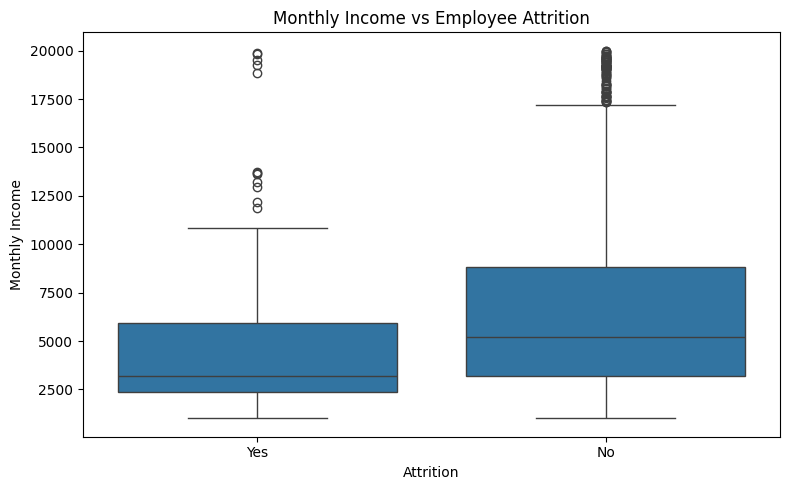

In [76]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title('Monthly Income vs Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.tight_layout()
plt.show()

In [77]:
department_attrition = pd.crosstab(
    data['Department'],
    data['Attrition'],
    normalize='index'
) * 100

print(department_attrition)

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


In [78]:
department_left = (
    data.groupby('Department')['Attrition_Flag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(department_left)

,Attrition_Flag
Department,
Sales,20.627803
Human Resources,19.047619
Research & Development,13.839750


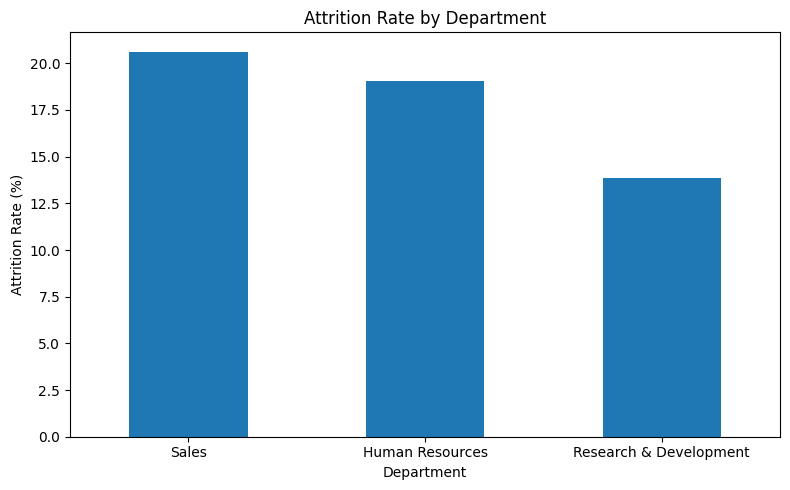

In [79]:
plt.figure(figsize=(8, 5))

department_left.plot(kind='bar')

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [80]:
overtime_attrition = (
    data.groupby('OverTime')['Attrition_Flag']
    .mean()
    .mul(100)
)

display(overtime_attrition)

,Attrition_Flag
OverTime,
No,10.436433
Yes,30.528846


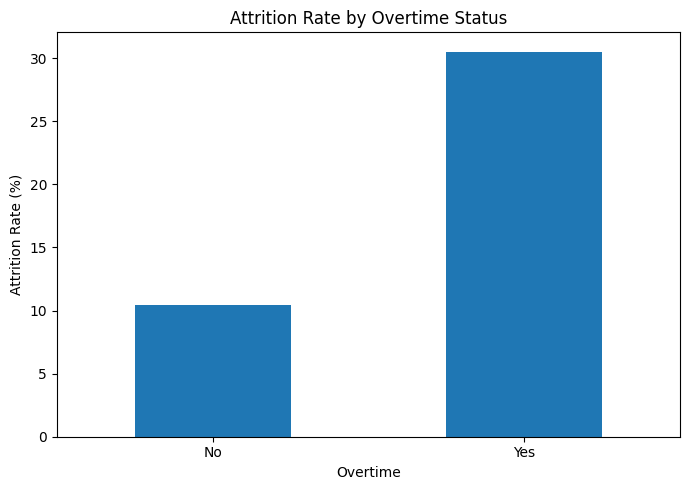

In [81]:
plt.figure(figsize=(7, 5))

overtime_attrition.plot(kind='bar')

plt.title('Attrition Rate by Overtime Status')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [82]:
overtime_satisfaction = data.groupby('OverTime')['JobSatisfaction'].mean()

display(overtime_satisfaction)

,JobSatisfaction
OverTime,
No,2.711575
Yes,2.771635


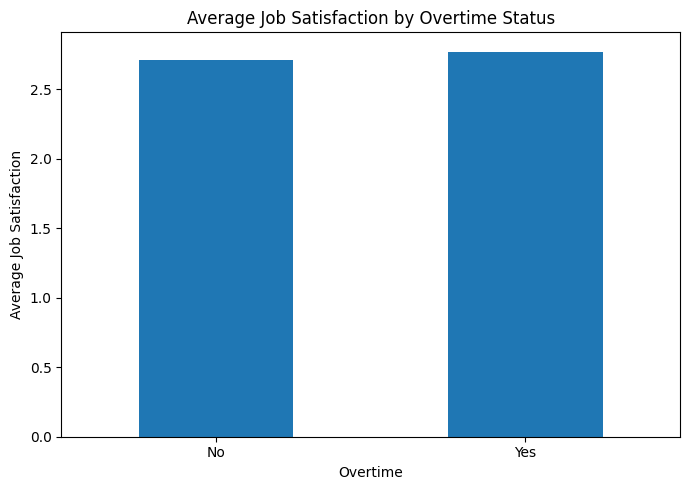

In [83]:
plt.figure(figsize=(7, 5))

overtime_satisfaction.plot(kind='bar')

plt.title('Average Job Satisfaction by Overtime Status')
plt.xlabel('Overtime')
plt.ylabel('Average Job Satisfaction')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [84]:
promotion_comparison = data.groupby('Attrition').agg(
    Average_Years_Since_Promotion=('YearsSinceLastPromotion', 'mean'),
    Median_Years_Since_Promotion=('YearsSinceLastPromotion', 'median')
)

display(promotion_comparison)

,Average_Years_Since_Promotion,Median_Years_Since_Promotion
Attrition,,
No,2.234388,1.0
Yes,1.945148,1.0


In [85]:
data['Promotion_Delay'] = pd.cut(
    data['YearsSinceLastPromotion'],
    bins=[-1, 1, 3, 5, 10, np.inf],
    labels=[
        '0-1 years',
        '2-3 years',
        '4-5 years',
        '6-10 years',
        '10+ years'
    ]
)

In [86]:
promotion_attrition = (
    data.groupby('Promotion_Delay', observed=True)['Attrition_Flag']
    .mean()
    .mul(100)
)

display(promotion_attrition)

,Attrition_Flag
Promotion_Delay,
0-1 years,16.950959
2-3 years,17.061611
4-5 years,6.603774
6-10 years,18.120805
10+ years,12.121212


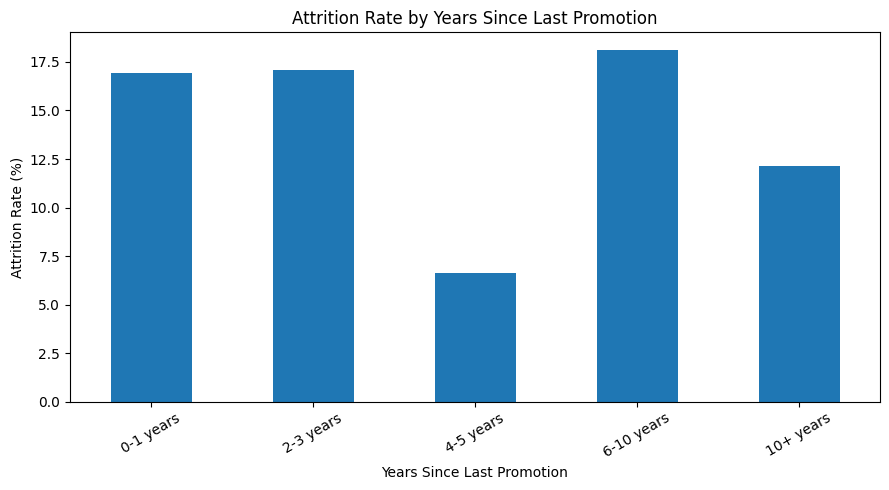

In [87]:
plt.figure(figsize=(9, 5))

promotion_attrition.plot(kind='bar')

plt.title('Attrition Rate by Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [88]:
role_attrition = (
    data.groupby('JobRole')['Attrition_Flag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(role_attrition)

,Attrition_Flag
JobRole,
Sales Representative,39.759036
Laboratory Technician,23.938224
Human Resources,23.076923
Sales Executive,17.484663
Research Scientist,16.095890
Manufacturing Director,6.896552
Healthcare Representative,6.870229
Manager,4.901961
Research Director,2.500000


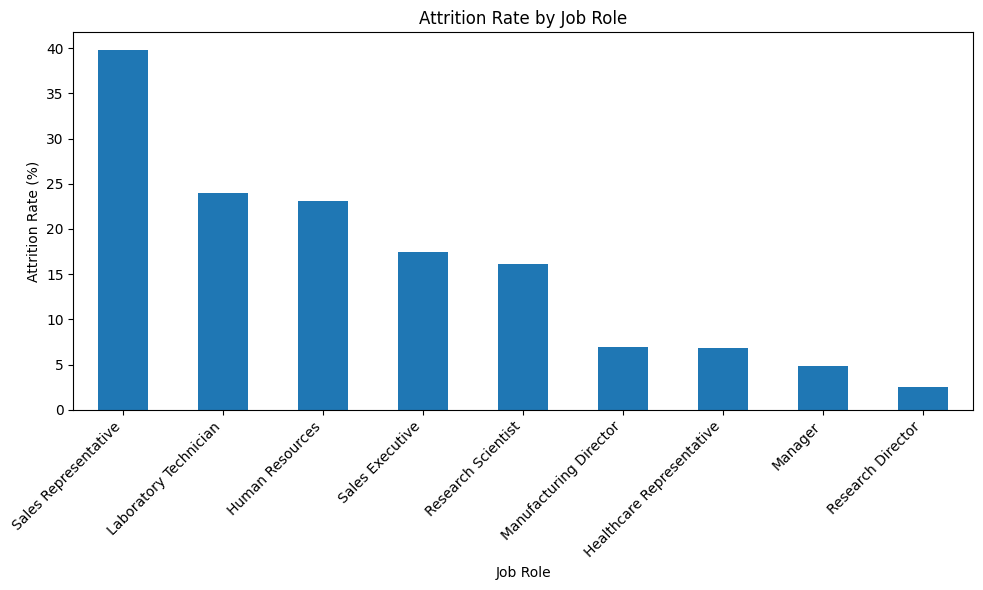

In [89]:
plt.figure(figsize=(10, 6))

role_attrition.plot(kind='bar')

plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [90]:
numerical_columns = [
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'JobInvolvement',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'TotalWorkingYears',
    'OverTime'
]

In [91]:
data['OverTime_Flag'] = data['OverTime'].map({
    'Yes': 1,
    'No': 0
})

In [92]:
corr_columns = [
    'Attrition_Flag',
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'JobInvolvement',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'TotalWorkingYears',
    'OverTime_Flag'
]

correlation = data[corr_columns].corr()

display(correlation)

,Attrition_Flag,Age,MonthlyIncome,JobSatisfaction,JobInvolvement,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,TotalWorkingYears,OverTime_Flag
Attrition_Flag,1.000000,-0.159205,-0.159840,-0.103481,-0.130016,-0.134392,-0.160545,-0.033019,-0.171063,0.246118
Age,-0.159205,1.000000,0.497855,-0.004892,0.029820,0.311309,0.212901,0.216513,0.680381,0.028062
MonthlyIncome,-0.159840,0.497855,1.000000,-0.007157,-0.015271,0.514285,0.363818,0.344978,0.772893,0.006089
JobSatisfaction,-0.103481,-0.004892,-0.007157,1.000000,-0.021476,-0.003803,-0.002305,-0.018214,-0.020185,0.024539
JobInvolvement,-0.130016,0.029820,-0.015271,-0.021476,1.000000,-0.021355,0.008717,-0.024184,-0.005533,-0.003507
YearsAtCompany,-0.134392,0.311309,0.514285,-0.003803,-0.021355,1.000000,0.758754,0.618409,0.628133,-0.011687
YearsInCurrentRole,-0.160545,0.212901,0.363818,-0.002305,0.008717,0.758754,1.000000,0.548056,0.460365,-0.029758
YearsSinceLastPromotion,-0.033019,0.216513,0.344978,-0.018214,-0.024184,0.618409,0.548056,1.000000,0.404858,-0.012239
TotalWorkingYears,-0.171063,0.680381,0.772893,-0.020185,-0.005533,0.628133,0.460365,0.404858,1.000000,0.012754
OverTime_Flag,0.246118,0.028062,0.006089,0.024539,-0.003507,-0.011687,-0.029758,-0.012239,0.012754,1.000000


In [93]:
features = [
    'Age',
    'MonthlyIncome',
    'JobLevel',
    'JobSatisfaction',
    'JobInvolvement',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'TotalWorkingYears',
    'OverTime_Flag'
]

X = data[features]

y = data['Attrition_Flag']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 13)
y shape: (1470,)


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1176, 13)
Testing: (294, 13)


In [95]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [96]:
y_pred = model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


In [97]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Random Forest Model Evaluation")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Random Forest Model Evaluation
--------------------------------
Accuracy : 0.8265
Precision: 0.4167
Recall   : 0.2128
F1 Score : 0.2817


In [98]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Stayed', 'Left'],
    zero_division=0
))

              precision    recall  f1-score   support

      Stayed       0.86      0.94      0.90       247
        Left       0.42      0.21      0.28        47

    accuracy                           0.83       294
   macro avg       0.64      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



In [99]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[233  14]
 [ 37  10]]


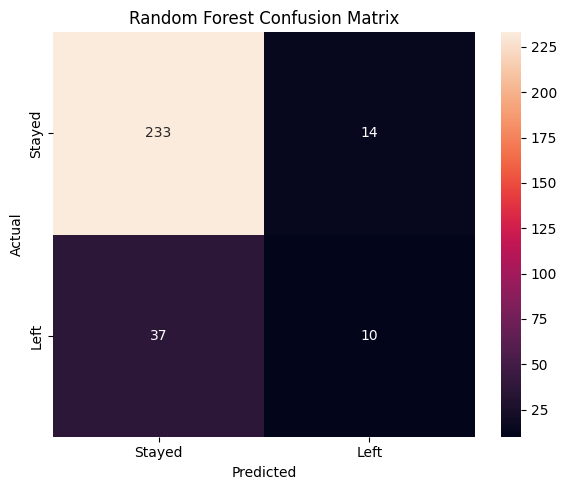

In [100]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [101]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,MonthlyIncome,0.153521
0,Age,0.131469
11,TotalWorkingYears,0.108587
8,YearsAtCompany,0.098764
12,OverTime_Flag,0.077384
9,YearsInCurrentRole,0.068298
5,EnvironmentSatisfaction,0.063558
3,JobSatisfaction,0.058461
10,YearsSinceLastPromotion,0.051092
6,RelationshipSatisfaction,0.048828


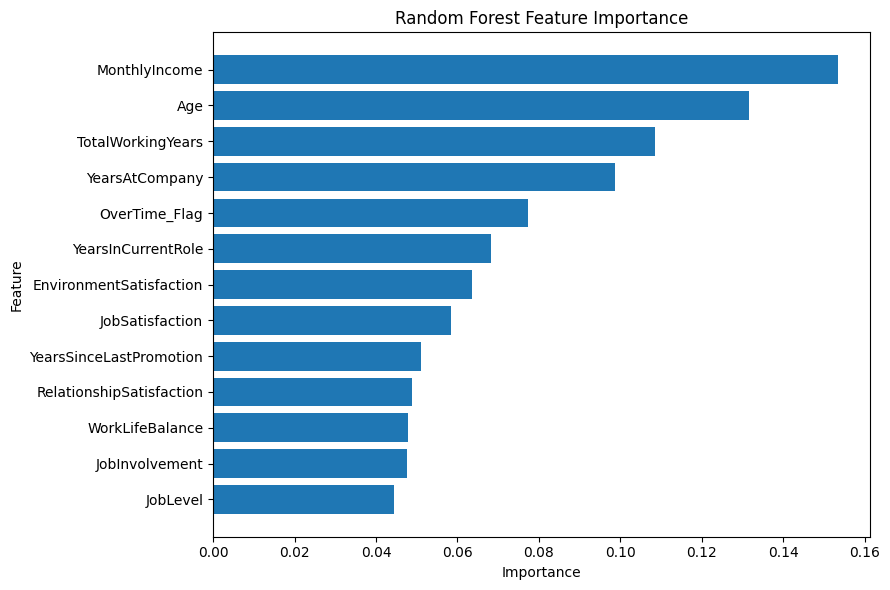

In [102]:
plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [103]:
final_summary = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Employees Left',
        'Employees Stayed',
        'Overall Attrition Rate',
        'Random Forest Accuracy',
        'Random Forest Precision',
        'Random Forest Recall',
        'Random Forest F1 Score'
    ],
    'Value': [
        len(data),
        data['Attrition_Flag'].sum(),
        (data['Attrition_Flag'] == 0).sum(),
        f"{attrition_rate:.2f}%",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}"
    ]
})

display(final_summary)

,Metric,Value
0,Total Employees,1470
1,Employees Left,237
2,Employees Stayed,1233
3,Overall Attrition Rate,16.12%
4,Random Forest Accuracy,0.8265
5,Random Forest Precision,0.4167
6,Random Forest Recall,0.2128
7,Random Forest F1 Score,0.2817


In [104]:
top_features = feature_importance.head(5)

print("Top 5 Random Forest Features:")
display(top_features)

Top 5 Random Forest Features:


,Feature,Importance
1,MonthlyIncome,0.153521
0,Age,0.131469
11,TotalWorkingYears,0.108587
8,YearsAtCompany,0.098764
12,OverTime_Flag,0.077384


In [105]:
print("=" * 50)
print("HR EMPLOYEE ATTRITION ANALYSIS - FINAL RESULTS")
print("=" * 50)

print(f"\nTotal Employees       : {len(data)}")
print(f"Employees Left        : {data['Attrition_Flag'].sum()}")
print(f"Employees Stayed      : {(data['Attrition_Flag'] == 0).sum()}")
print(f"Overall Attrition     : {attrition_rate:.2f}%")

print("\nRANDOM FOREST RESULTS")
print(f"Accuracy              : {accuracy:.4f}")
print(f"Precision             : {precision:.4f}")
print(f"Recall                : {recall:.4f}")
print(f"F1 Score              : {f1:.4f}")

print("\nTOP IMPORTANT FEATURES")
display(feature_importance.head(10))

HR EMPLOYEE ATTRITION ANALYSIS - FINAL RESULTS

Total Employees       : 1470
Employees Left        : 237
Employees Stayed      : 1233
Overall Attrition     : 16.12%

RANDOM FOREST RESULTS
Accuracy              : 0.8265
Precision             : 0.4167
Recall                : 0.2128
F1 Score              : 0.2817

TOP IMPORTANT FEATURES


,Feature,Importance
1,MonthlyIncome,0.153521
0,Age,0.131469
11,TotalWorkingYears,0.108587
8,YearsAtCompany,0.098764
12,OverTime_Flag,0.077384
9,YearsInCurrentRole,0.068298
5,EnvironmentSatisfaction,0.063558
3,JobSatisfaction,0.058461
10,YearsSinceLastPromotion,0.051092
6,RelationshipSatisfaction,0.048828


In [106]:
highest_department = department_left.idxmax()
highest_department_rate = department_left.max()

print("Department with highest observed attrition rate:")
print(highest_department)
print(f"Rate: {highest_department_rate:.2f}%")

Department with highest observed attrition rate:
Sales
Rate: 20.63%


In [107]:
print("Attrition by Promotion Delay:")
display(promotion_attrition)

Attrition by Promotion Delay:


,Attrition_Flag
Promotion_Delay,
0-1 years,16.950959
2-3 years,17.061611
4-5 years,6.603774
6-10 years,18.120805
10+ years,12.121212


In [108]:
data.to_csv('/content/hr_attrition_cleaned.csv', index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [109]:
!pip install streamlit pyngrok -q

In [110]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# PAGE CONFIGURATION
# -----------------------------

st.set_page_config(
    page_title="HR Attrition Dashboard",
    page_icon="👥",
    layout="wide"
)

# -----------------------------
# LOAD DATA
# -----------------------------

data = pd.read_csv("/content/hr_attrition_cleaned.csv")

# Attrition encoding
data["Attrition_Flag"] = data["Attrition"].map({
    "Yes": 1,
    "No": 0
})

# -----------------------------
# TITLE
# -----------------------------

st.title("👥 HR Employee Attrition Dashboard")
st.markdown(
    "Interactive analysis of employee turnover, satisfaction, "
    "overtime, salary and promotion patterns."
)

st.divider()

# -----------------------------
# SIDEBAR FILTERS
# -----------------------------

st.sidebar.header("Dashboard Filters")

departments = ["All"] + sorted(data["Department"].unique().tolist())

selected_department = st.sidebar.selectbox(
    "Department",
    departments
)

overtime_options = ["All"] + sorted(data["OverTime"].unique().tolist())

selected_overtime = st.sidebar.selectbox(
    "Overtime",
    overtime_options
)

filtered_data = data.copy()

if selected_department != "All":
    filtered_data = filtered_data[
        filtered_data["Department"] == selected_department
    ]

if selected_overtime != "All":
    filtered_data = filtered_data[
        filtered_data["OverTime"] == selected_overtime
    ]

# -----------------------------
# KPI CARDS
# -----------------------------

total_employees = len(filtered_data)

employees_left = filtered_data["Attrition_Flag"].sum()

attrition_rate = (
    filtered_data["Attrition_Flag"].mean() * 100
    if total_employees > 0
    else 0
)

avg_income = (
    filtered_data["MonthlyIncome"].mean()
    if total_employees > 0
    else 0
)

avg_satisfaction = (
    filtered_data["JobSatisfaction"].mean()
    if total_employees > 0
    else 0
)

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Employees",
    total_employees
)

col2.metric(
    "Employees Left",
    employees_left
)

col3.metric(
    "Attrition Rate",
    f"{attrition_rate:.2f}%"
)

col4.metric(
    "Avg Job Satisfaction",
    f"{avg_satisfaction:.2f}"
)

st.divider()

# -----------------------------
# ROW 1
# -----------------------------

col1, col2 = st.columns(2)

# Department chart
with col1:

    dept_data = (
        filtered_data.groupby("Department")["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    dept_data.columns = [
        "Department",
        "Attrition Rate"
    ]

    fig1 = px.bar(
        dept_data,
        x="Department",
        y="Attrition Rate",
        title="Attrition Rate by Department",
        text_auto=".2f"
    )

    st.plotly_chart(
        fig1,
        use_container_width=True
    )

# Overtime chart
with col2:

    overtime_data = (
        filtered_data.groupby("OverTime")["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    overtime_data.columns = [
        "OverTime",
        "Attrition Rate"
    ]

    fig2 = px.bar(
        overtime_data,
        x="OverTime",
        y="Attrition Rate",
        title="Attrition Rate by Overtime",
        text_auto=".2f"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )

# -----------------------------
# ROW 2
# -----------------------------

col1, col2 = st.columns(2)

# Salary vs Attrition
with col1:

    fig3 = px.box(
        filtered_data,
        x="Attrition",
        y="MonthlyIncome",
        title="Monthly Income vs Attrition"
    )

    st.plotly_chart(
        fig3,
        use_container_width=True
    )

# Promotion delay
with col2:

    promotion_data = (
        filtered_data.groupby(
            "YearsSinceLastPromotion"
        )["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    promotion_data.columns = [
        "Years Since Last Promotion",
        "Attrition Rate"
    ]

    fig4 = px.line(
        promotion_data,
        x="Years Since Last Promotion",
        y="Attrition Rate",
        markers=True,
        title="Promotion Delay vs Attrition"
    )

    st.plotly_chart(
        fig4,
        use_container_width=True
    )

# -----------------------------
# JOB ROLE ANALYSIS
# -----------------------------

st.subheader("Job Role Analysis")

role_data = (
    filtered_data.groupby("JobRole")["Attrition_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

role_data.columns = [
    "Job Role",
    "Attrition Rate"
]

fig5 = px.bar(
    role_data,
    x="Job Role",
    y="Attrition Rate",
    title="Attrition Rate by Job Role",
    text_auto=".2f"
)

fig5.update_layout(
    xaxis_tickangle=-45
)

st.plotly_chart(
    fig5,
    use_container_width=True
)

# -----------------------------
# SATISFACTION ANALYSIS
# -----------------------------

st.subheader("Overtime and Job Satisfaction")

satisfaction_data = (
    filtered_data.groupby("OverTime")["JobSatisfaction"]
    .mean()
    .reset_index()
)

fig6 = px.bar(
    satisfaction_data,
    x="OverTime",
    y="JobSatisfaction",
    title="Average Job Satisfaction by Overtime"
)

st.plotly_chart(
    fig6,
    use_container_width=True
)

# -----------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# -----------------------------

st.subheader("Random Forest Feature Importance")

features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "JobSatisfaction",
    "JobInvolvement",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "TotalWorkingYears",
    "OverTime_Flag"
]

# Make sure the overtime flag exists
filtered_data["OverTime_Flag"] = filtered_data["OverTime"].map({
    "Yes": 1,
    "No": 0
})

X = filtered_data[features].fillna(0)
y = filtered_data["Attrition_Flag"]

if len(filtered_data) > 10 and y.nunique() == 2:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X, y)

    importance = pd.DataFrame({
        "Feature": features,
        "Importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=True
    )

    fig7 = px.bar(
        importance,
        x="Importance",
        y="Feature",
        orientation="h",
        title="Random Forest Feature Importance"
    )

    st.plotly_chart(
        fig7,
        use_container_width=True
    )

# -----------------------------
# DATA TABLE
# -----------------------------

st.subheader("Filtered Employee Data")

st.dataframe(
    filtered_data,
    use_container_width=True
)

# -----------------------------
# FOOTER
# -----------------------------

st.divider()

st.caption(
    "HR Employee Attrition Analysis | Random Forest | "
    "Interactive Dashboard"
)

Overwriting app.py


In [111]:
!streamlit run app.py &>/content/logs.txt &

In [112]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [113]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [114]:
!pkill -f streamlit

In [115]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [116]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [117]:
!cat /content/streamlit.log

In [118]:
!pkill -f streamlit

In [119]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableXsrfProtection false \
    --server.enableCORS false \
    --server.headless true \
    &>/content/streamlit.log &

In [120]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [121]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier

# =========================
# PAGE CONFIG
# =========================

st.set_page_config(
    page_title="HR Employee Attrition Dashboard",
    page_icon="👥",
    layout="wide"
)

# =========================
# LOAD DATA
# =========================

data = pd.read_csv("/content/hr_attrition_cleaned.csv")

data["Attrition_Flag"] = data["Attrition"].map({
    "Yes": 1,
    "No": 0
})

data["OverTime_Flag"] = data["OverTime"].map({
    "Yes": 1,
    "No": 0
})

# =========================
# HEADER
# =========================

st.title("👥 HR Employee Attrition Dashboard")

st.markdown(
    "### Employee turnover, satisfaction, overtime, salary and career progression analysis"
)

st.divider()

# =========================
# SIDEBAR
# =========================

st.sidebar.header("🔎 Dashboard Filters")

department_options = ["All"] + sorted(
    data["Department"].dropna().unique().tolist()
)

overtime_options = ["All"] + sorted(
    data["OverTime"].dropna().unique().tolist()
)

selected_department = st.sidebar.selectbox(
    "Department",
    department_options
)

selected_overtime = st.sidebar.selectbox(
    "Overtime",
    overtime_options
)

filtered_data = data.copy()

if selected_department != "All":
    filtered_data = filtered_data[
        filtered_data["Department"] == selected_department
    ]

if selected_overtime != "All":
    filtered_data = filtered_data[
        filtered_data["OverTime"] == selected_overtime
    ]

# =========================
# KPI CALCULATIONS
# =========================

total_employees = len(filtered_data)

employees_left = int(
    filtered_data["Attrition_Flag"].sum()
)

attrition_rate = (
    filtered_data["Attrition_Flag"].mean() * 100
    if total_employees > 0
    else 0
)

avg_income = (
    filtered_data["MonthlyIncome"].mean()
    if total_employees > 0
    else 0
)

avg_satisfaction = (
    filtered_data["JobSatisfaction"].mean()
    if total_employees > 0
    else 0
)

# =========================
# KPI CARDS
# =========================

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "👥 Total Employees",
    f"{total_employees:,}"
)

col2.metric(
    "🚪 Employees Left",
    f"{employees_left:,}"
)

col3.metric(
    "📉 Attrition Rate",
    f"{attrition_rate:.2f}%"
)

col4.metric(
    "😊 Avg Satisfaction",
    f"{avg_satisfaction:.2f}/4"
)

st.divider()

# =========================
# DEPARTMENT ANALYSIS
# =========================

col1, col2 = st.columns(2)

with col1:

    dept_data = (
        filtered_data.groupby("Department")["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    dept_data.columns = [
        "Department",
        "Attrition Rate"
    ]

    fig1 = px.bar(
        dept_data,
        x="Department",
        y="Attrition Rate",
        title="Attrition Rate by Department",
        text_auto=".2f"
    )

    fig1.update_layout(
        yaxis_title="Attrition Rate (%)"
    )

    st.plotly_chart(
        fig1,
        use_container_width=True
    )

# =========================
# OVERTIME ANALYSIS
# =========================

with col2:

    overtime_data = (
        filtered_data.groupby("OverTime")["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    overtime_data.columns = [
        "OverTime",
        "Attrition Rate"
    ]

    fig2 = px.bar(
        overtime_data,
        x="OverTime",
        y="Attrition Rate",
        title="Attrition Rate by Overtime",
        text_auto=".2f"
    )

    fig2.update_layout(
        yaxis_title="Attrition Rate (%)"
    )

    st.plotly_chart(
        fig2,
        use_container_width=True
    )

# =========================
# SALARY + PROMOTION
# =========================

col1, col2 = st.columns(2)

with col1:

    fig3 = px.box(
        filtered_data,
        x="Attrition",
        y="MonthlyIncome",
        title="Monthly Income vs Attrition"
    )

    st.plotly_chart(
        fig3,
        use_container_width=True
    )

with col2:

    promotion_data = (
        filtered_data.groupby(
            "YearsSinceLastPromotion"
        )["Attrition_Flag"]
        .mean()
        .mul(100)
        .reset_index()
    )

    promotion_data.columns = [
        "Years Since Last Promotion",
        "Attrition Rate"
    ]

    fig4 = px.line(
        promotion_data,
        x="Years Since Last Promotion",
        y="Attrition Rate",
        markers=True,
        title="Promotion Delay vs Attrition"
    )

    st.plotly_chart(
        fig4,
        use_container_width=True
    )

# =========================
# JOB ROLE
# =========================

st.subheader("💼 Attrition by Job Role")

role_data = (
    filtered_data.groupby("JobRole")["Attrition_Flag"]
    .mean()
    .mul(100)
    .reset_index()
)

role_data.columns = [
    "Job Role",
    "Attrition Rate"
]

fig5 = px.bar(
    role_data,
    x="Job Role",
    y="Attrition Rate",
    title="Attrition Rate by Job Role",
    text_auto=".2f"
)

fig5.update_layout(
    xaxis_tickangle=-45
)

st.plotly_chart(
    fig5,
    use_container_width=True
)

# =========================
# OVERTIME + SATISFACTION
# =========================

st.subheader("😊 Overtime and Job Satisfaction")

satisfaction_data = (
    filtered_data.groupby("OverTime")["JobSatisfaction"]
    .mean()
    .reset_index()
)

fig6 = px.bar(
    satisfaction_data,
    x="OverTime",
    y="JobSatisfaction",
    title="Average Job Satisfaction by Overtime"
)

st.plotly_chart(
    fig6,
    use_container_width=True
)

# =========================
# RANDOM FOREST
# =========================

st.subheader("🤖 Random Forest Feature Importance")

features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "JobSatisfaction",
    "JobInvolvement",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "TotalWorkingYears",
    "OverTime_Flag"
]

X = filtered_data[features].fillna(0)
y = filtered_data["Attrition_Flag"]

if len(filtered_data) > 10 and y.nunique() == 2:

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )

    rf.fit(X, y)

    importance = pd.DataFrame({
        "Feature": features,
        "Importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=True
    )

    fig7 = px.bar(
        importance,
        x="Importance",
        y="Feature",
        orientation="h",
        title="Factors Used by Random Forest"
    )

    st.plotly_chart(
        fig7,
        use_container_width=True
    )

else:

    st.info(
        "Select filters that contain both attrition classes "
        "to calculate Random Forest feature importance."
    )

# =========================
# KEY INSIGHTS
# =========================

st.divider()

st.header("💡 Key Insights")

if len(filtered_data) > 0:

    dept_rates = (
        filtered_data.groupby("Department")["Attrition_Flag"]
        .mean()
        .mul(100)
    )

    overtime_rates = (
        filtered_data.groupby("OverTime")["Attrition_Flag"]
        .mean()
        .mul(100)
    )

    highest_dept = dept_rates.idxmax()
    highest_dept_rate = dept_rates.max()

    highest_overtime = overtime_rates.idxmax()
    highest_overtime_rate = overtime_rates.max()

    st.write(
        f"• The observed overall attrition rate in the current filter "
        f"is **{attrition_rate:.2f}%**."
    )

    st.write(
        f"• **{highest_dept}** has the highest observed attrition rate "
        f"among the departments shown (**{highest_dept_rate:.2f}%**)."
    )

    st.write(
        f"• The **{highest_overtime}** overtime group has the higher "
        f"observed attrition rate (**{highest_overtime_rate:.2f}%**)."
    )

    st.write(
        f"• Average job satisfaction in the current selection is "
        f"**{avg_satisfaction:.2f}/4**."
    )

    st.write(
        "• Salary, overtime, satisfaction, workload-related variables "
        "and career progression should be examined together rather "
        "than treating one variable as the sole explanation for attrition."
    )

# =========================
# ACTION PLAN
# =========================

st.header("📌 Practical HR Action Plan")

st.markdown("""
- Monitor departments with relatively high observed attrition.
- Review overtime and workload patterns.
- Examine satisfaction among employees working overtime.
- Review career progression and promotion timelines.
- Evaluate compensation alongside other employee factors.
- Use the Random Forest feature-importance results to identify
  areas for further investigation.
- Repeat the analysis periodically with updated employee data.
""")

# =========================
# DATA TABLE
# =========================

st.divider()

st.subheader("📋 Filtered Employee Data")

st.dataframe(
    filtered_data,
    use_container_width=True
)

st.divider()

st.caption(
    "HR Employee Attrition Analysis | Random Forest | Interactive Dashboard"
)

Overwriting app.py


In [122]:
!pkill -f streamlit

In [123]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableXsrfProtection false \
    --server.enableCORS false \
    --server.headless true \
    &>/content/streamlit.log &

In [124]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [125]:
from google.colab import output

url = output.serve_kernel_port_as_window(8501)
print(url)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

None
